Importing and exploring the data

In [2]:
# Data manipulation and Numerical computing
import pandas as pd  
import numpy as np  

# plots and visualisations
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('E:/Semester 4 (Intelligent System)/Natural Languange Proccesing/Lec/Project/Dataset/email.csv', encoding='latin-1')

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5573, 2)


In [5]:
#baca datanya 
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
#nama column nya 
df.columns

Index(['Category', 'Message'], dtype='object')

In [7]:
#Missing Values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [8]:
#cek duplikat rows
df.duplicated().sum()

415

In [9]:
print("=== LABEL CATEGORY Persentase ===")
label_counts = df['Category'].value_counts()
label_percentages = df['Category'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percentages
})
print(label_summary)

=== LABEL CATEGORY Persentase ===
                Count  Percentage
Category                         
ham              4825   86.578145
spam              747   13.403912
{"mode":"full"      1    0.017944


Data Preprocessing

In [10]:
# Remove rows with non-standard categories
print(f"Before cleaning categories: {df.shape[0]} rows")
df = df[df['Category'].isin(['ham', 'spam'])]
print(f"After cleaning categories: {df.shape[0]} rows")

Before cleaning categories: 5573 rows
After cleaning categories: 5572 rows


In [11]:
# Remove duplicate rows
print(f"Before removing duplicates: {df.shape[0]} rows")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]} rows")

Before removing duplicates: 5572 rows
After removing duplicates: 5157 rows


Text Cleaning

In [12]:
import re # text processing
import nltk # Natural Language Processing NLP
from nltk.corpus import stopwords # remove common words (like 'the', 'a', 'is')
from nltk.stem import PorterStemmer # reduce words to their root form ("running" -> "run")

In [13]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters, numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Apply stemming
    words = [stemmer.stem(word) for word in words]
    
    return ' '.join(words)

In [15]:
# Apply cleaning
df['cleaned_message'] = df['Message'].apply(clean_text)

In [16]:
df.head()

,Category,Message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


Feature Engineering

In [17]:
# Create additional features
df['message_length'] = df['Message'].apply(len)
df['word_count'] = df['Message'].apply(lambda x: len(x.split()))
df['has_currency'] = df['Message'].apply(lambda x: 1 if re.search(r'[$£€¥]', x) else 0)
df['has_numbers'] = df['Message'].apply(lambda x: 1 if re.search(r'\d', x) else 0)
df['has_special_chars'] = df['Message'].apply(lambda x: 1 if re.search(r'[!@#$%^&*()]', x) else 0)
df['has_urgent_words'] = df['Message'].apply(lambda x: 1 if re.search(r'\b(urgent|free|prize|winner|cash|guarantee)\b', x.lower()) else 0)

Label Encoding

In [18]:
# Convert categorical labels to numerical
df['label'] = df['Category'].map({'ham': 0, 'spam': 1})

In [19]:
df.columns

Index(['Category', 'Message', 'cleaned_message', 'message_length',
       'word_count', 'has_currency', 'has_numbers', 'has_special_chars',
       'has_urgent_words', 'label'],
      dtype='object')

Text Vectorization

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization 
tfidf = TfidfVectorizer(
    max_features=5000,   # use top 5000 terms
    ngram_range=(1, 2),  # Include bigrams (two-word phrases, like "data science")
    min_df=2,            # Ignore terms that appear in less than 2 mails
    max_df=0.8           # Ignore terms that appear in more than 80% of mails
)

encoded = tfidf.fit_transform(df['cleaned_message'])

Data Spliting

In [21]:
y= df['label']
DF = df.drop(['Category', 'cleaned_message', 'Message', 'label'], axis=1)
DF.columns

Index(['message_length', 'word_count', 'has_currency', 'has_numbers',
       'has_special_chars', 'has_urgent_words'],
      dtype='object')

In [22]:
# combine the text features and engineered features
#from scipy.sparse import hstack

X = encoded

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

In [24]:
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Training features shape: (4125, 5000)
Test features shape: (1032, 5000)


Model learning

In [25]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [26]:
# Train the model
nb_model.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [27]:
X_test

<1032x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 9358 stored elements in Compressed Sparse Row format>

In [28]:
# test the model
y_pred_nb = nb_model.predict(X_test)

Model Evaluation

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve

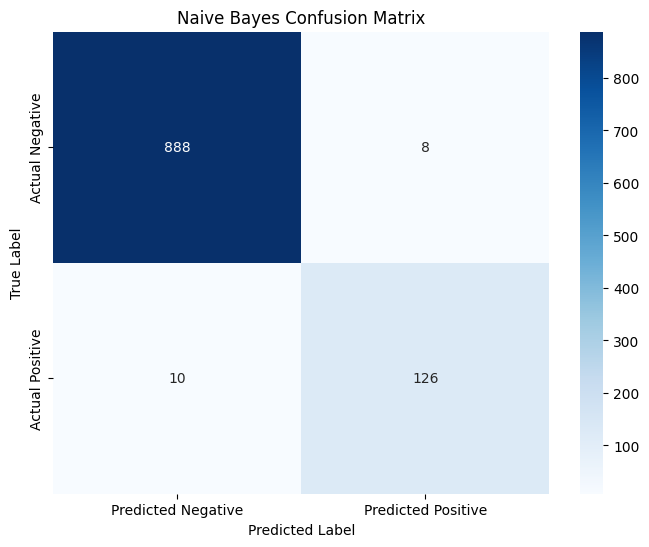

In [34]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)

# Display confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Naive Bayes Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [35]:
rf_acc = accuracy_score(y_test, y_pred_nb)
rf_pr = precision_score(y_test, y_pred_nb)
rf_rec = recall_score(y_test, y_pred_nb)
rf_f1 = f1_score(y_test, y_pred_nb)

In [36]:
print(f"Accuracy: {rf_acc:.4f}")
print(f"Precision: {rf_pr:.4f}")
print(f"Recall: {rf_rec:.4f}")
print(f"F1 score: {rf_f1:.4f}")

Accuracy: 0.9826
Precision: 0.9403
Recall: 0.9265
F1 score: 0.9333


In [37]:
import joblib

joblib.dump(nb_model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']